# Bank Marketing Campaign: Customer Conversion Analysis

**Business Question:** What customer profiles and behaviours predict conversion, 
and what does that tell us about how the business should prioritise its outreach 
and product strategy?

**Audience:** Strategy Team, with findings relevant to Marketing and Customer Experience.

**Success Metric:** A clear narrative ending with specific, actionable recommendations 
a non-technical stakeholder can take into a meeting.

# Act 1: Who Are Our Customers?
## Data Cleaning & Demographic Analysis

In [1]:
import pandas as pd
df = pd.read_csv('bank-full.csv', sep=';')
print(df)

       age           job   marital  education  ... pdays  previous poutcome    y
0       58    management   married   tertiary  ...    -1         0  unknown   no
1       44    technician    single  secondary  ...    -1         0  unknown   no
2       33  entrepreneur   married  secondary  ...    -1         0  unknown   no
3       47   blue-collar   married    unknown  ...    -1         0  unknown   no
4       33       unknown    single    unknown  ...    -1         0  unknown   no
...    ...           ...       ...        ...  ...   ...       ...      ...  ...
45206   51    technician   married   tertiary  ...    -1         0  unknown  yes
45207   71       retired  divorced    primary  ...    -1         0  unknown  yes
45208   72       retired   married  secondary  ...   184         3  success  yes
45209   57   blue-collar   married  secondary  ...    -1         0  unknown   no
45210   37  entrepreneur   married  secondary  ...   188        11    other   no

[45211 rows x 17 columns]


In [2]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [3]:
import numpy as np
df['pdays'] = df['pdays'].replace(-1, np.nan)
df['pdays'].describe()

count    8257.000000
mean      224.577692
std       115.344035
min         1.000000
25%       133.000000
50%       194.000000
75%       327.000000
max       871.000000
Name: pdays, dtype: float64

In [4]:
df = df.replace('unknown', np.nan)
df = df[df['duration'] != 0]
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45208 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        45208 non-null  int64  
 1   job        44920 non-null  object 
 2   marital    45208 non-null  object 
 3   education  43351 non-null  object 
 4   default    45208 non-null  object 
 5   balance    45208 non-null  int64  
 6   housing    45208 non-null  object 
 7   loan       45208 non-null  object 
 8   contact    32189 non-null  object 
 9   day        45208 non-null  int64  
 10  month      45208 non-null  object 
 11  duration   45208 non-null  int64  
 12  campaign   45208 non-null  int64  
 13  pdays      8257 non-null   float64
 14  previous   45208 non-null  int64  
 15  poutcome   8252 non-null   object 
 16  y          45208 non-null  object 
dtypes: float64(1), int64(6), object(10)
memory usage: 6.2+ MB


In [5]:
df['was_previously_contacted'] = df['pdays'].apply(lambda x: 0 if pd.isna(x) else 1)

In [6]:
df['poutcome'] = df['poutcome'].fillna('no_previous')
df = df.dropna(subset= ['contact', 'job', 'education'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30905 entries, 12657 to 45210
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       30905 non-null  int64  
 1   job                       30905 non-null  object 
 2   marital                   30905 non-null  object 
 3   education                 30905 non-null  object 
 4   default                   30905 non-null  object 
 5   balance                   30905 non-null  int64  
 6   housing                   30905 non-null  object 
 7   loan                      30905 non-null  object 
 8   contact                   30905 non-null  object 
 9   day                       30905 non-null  int64  
 10  month                     30905 non-null  object 
 11  duration                  30905 non-null  int64  
 12  campaign                  30905 non-null  int64  
 13  pdays                     7847 non-null   float64
 14  previou

In [7]:
binary_cols = ['default', 'housing', 'loan', 'y']
df[binary_cols] = df[binary_cols].replace({'yes': 1, 'no': 0})
df[binary_cols].head()

,default,housing,loan,y
12657,0,0,0,0
12658,0,0,0,0
12659,0,0,1,0
12660,0,0,0,0
12661,0,1,1,0


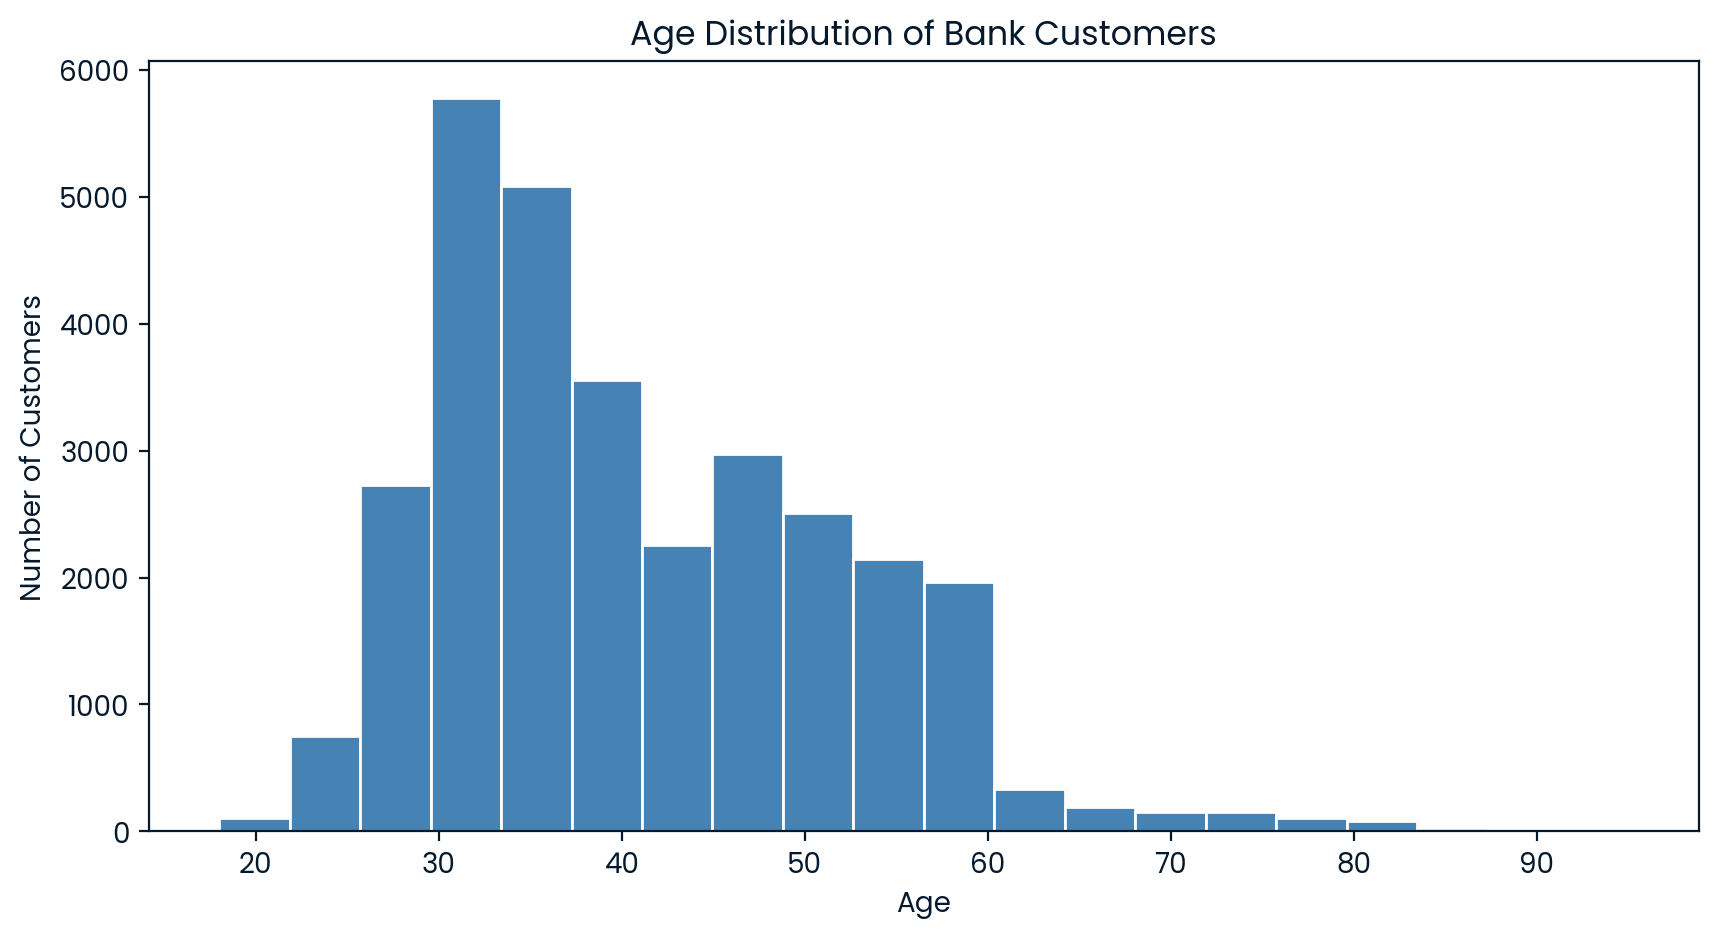

In [8]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.hist(df['age'], bins=20, color='steelblue', edgecolor='white')
plt.title('Age Distribution of Bank Customers')
plt.xlabel('Age')
plt.ylabel('Number of Customers')
plt.show()

## Insight 1: Age Distribution
The customer base is concentrated between ages 25 and 45, consistent with typical digital banking adoption patterns. However, a secondary cluster exists between 50 and 65, representing an underexplored segment. As older adults increasingly adopt digital financial tools, particularly in the lead-up to retirement, this group presents a meaningful growth opportunity. Targeted product messaging around retirement planning and financial security could convert this passive segment into active, high-value customers.

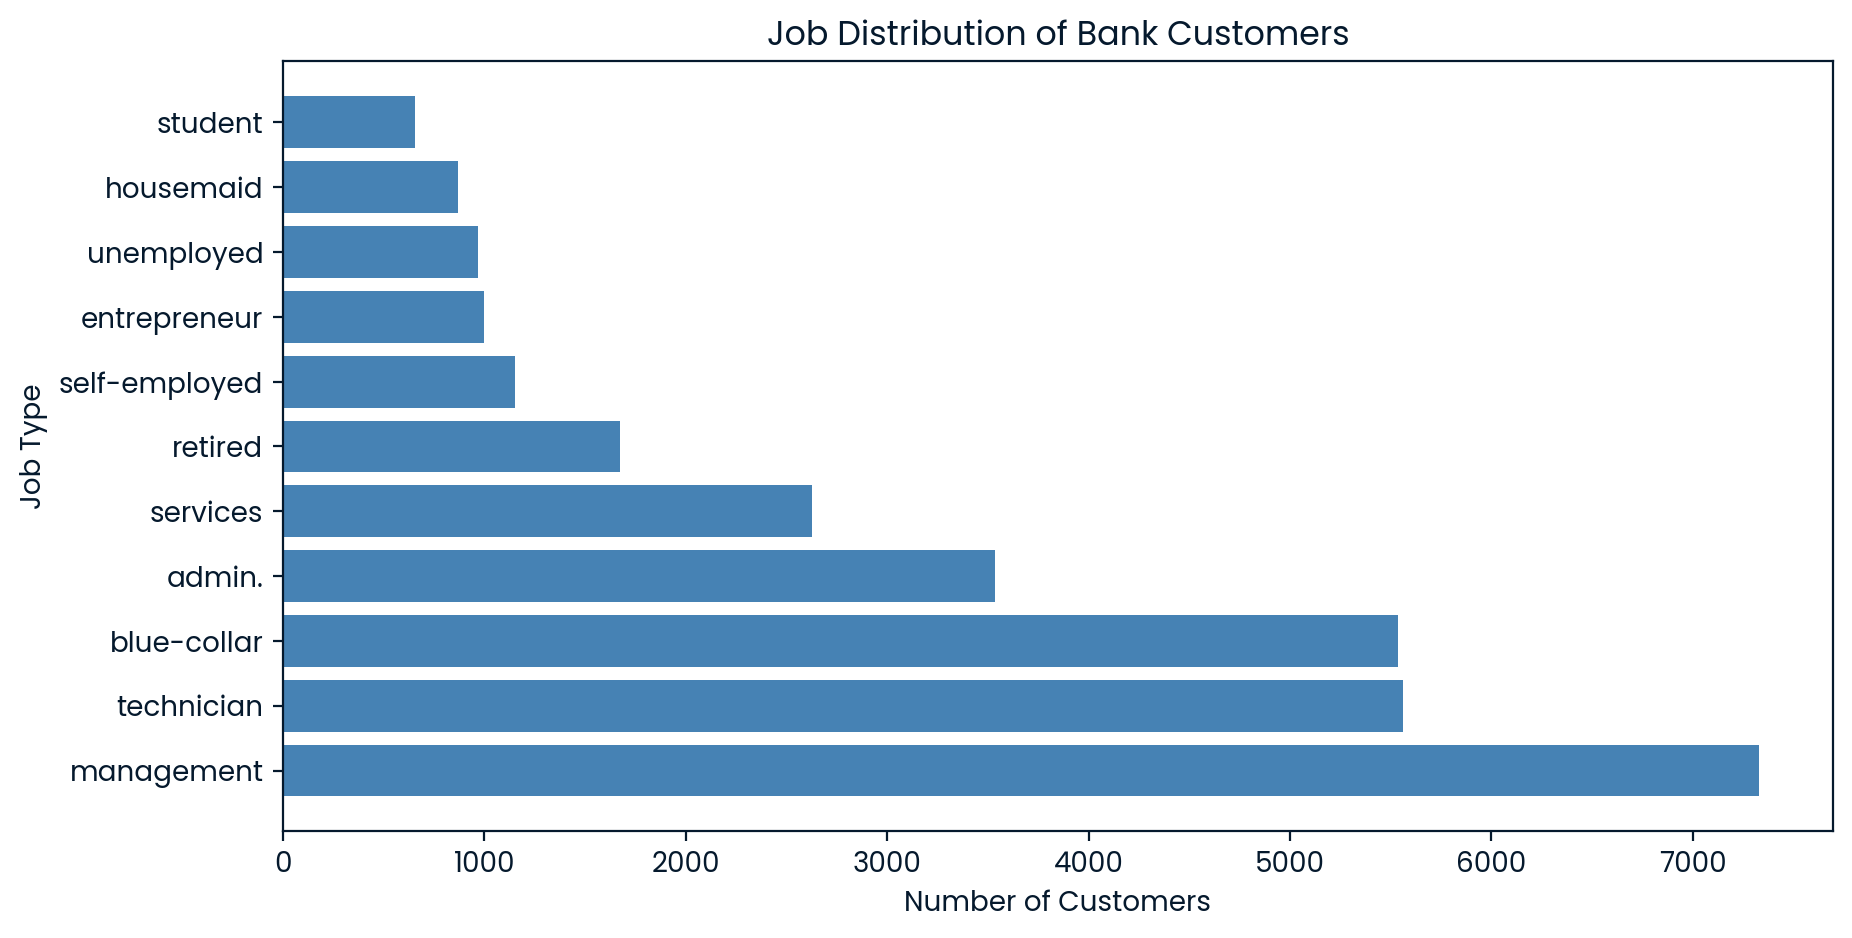

In [10]:
job_counts = df['job'].value_counts()

plt.figure(figsize=(10, 5))
plt.barh(job_counts.index, job_counts.values, color='steelblue')
plt.title('Job Distribution of Bank Customers')
plt.xlabel('Number of Customers')
plt.ylabel('Job Type')
plt.show()


## Insight 2: Job Distribution

The three largest customer segments are management, technician, and blue-collar workers, 
representing significantly different income levels and financial needs. Despite being 
grouped together as the bank's core audience, these segments likely require distinct 
product messaging and outreach strategies. A segmented campaign approach, tailored to 
income level, digital comfort, and financial priorities, would likely outperform a 
single broad campaign across all job types.

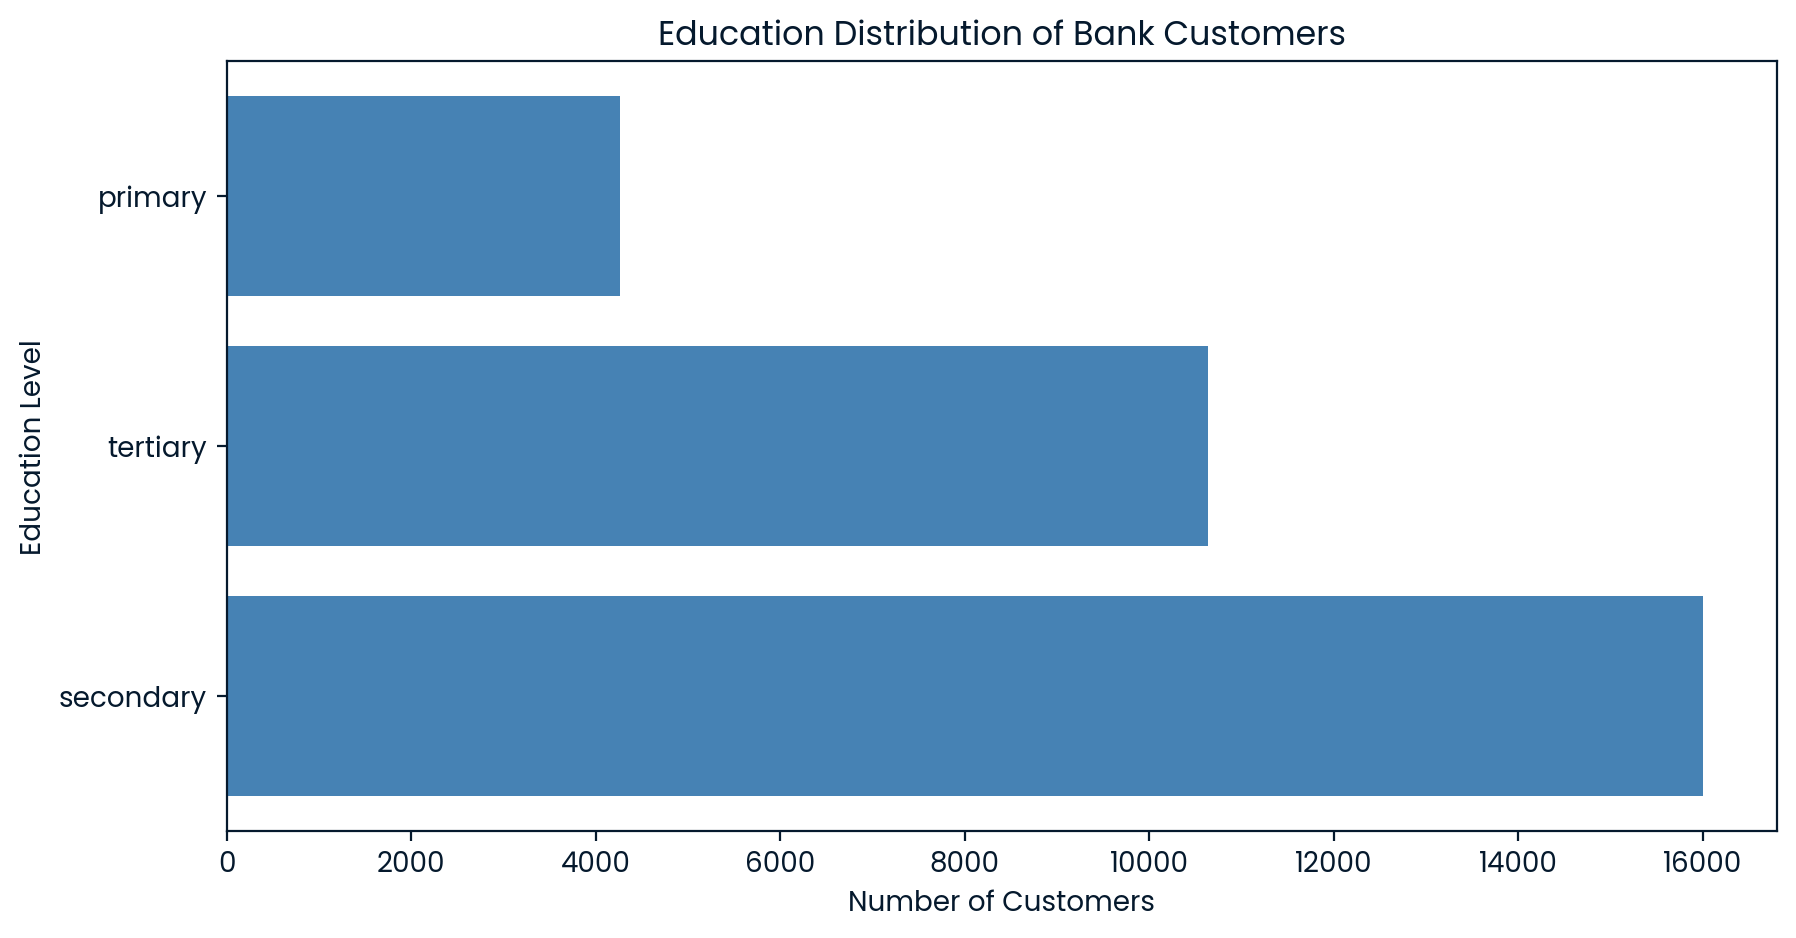

In [12]:
edu_counts = df['education'].value_counts()

plt.figure(figsize=(10, 5))
plt.barh(edu_counts.index, edu_counts.values, color='steelblue')
plt.title('Education Distribution of Bank Customers')
plt.xlabel('Number of Customers')
plt.ylabel('Education Level')
plt.show()


## Insight 3: Education Distribution

Our customer base skews toward secondary educated individuals at 16,000, nearly double 
the tertiary segment at 10,000. This means overall conversion volume will likely be 
driven by secondary educated customers simply due to size. However tertiary educated 
customers, with higher financial literacy, may convert at a better rate. The business 
should track both metrics separately rather than relying on total conversions alone, 
as the two segments likely respond to different messaging and product framing.

# Act 2: What Is Their Financial Picture?
## Financial Behaviour Analysis

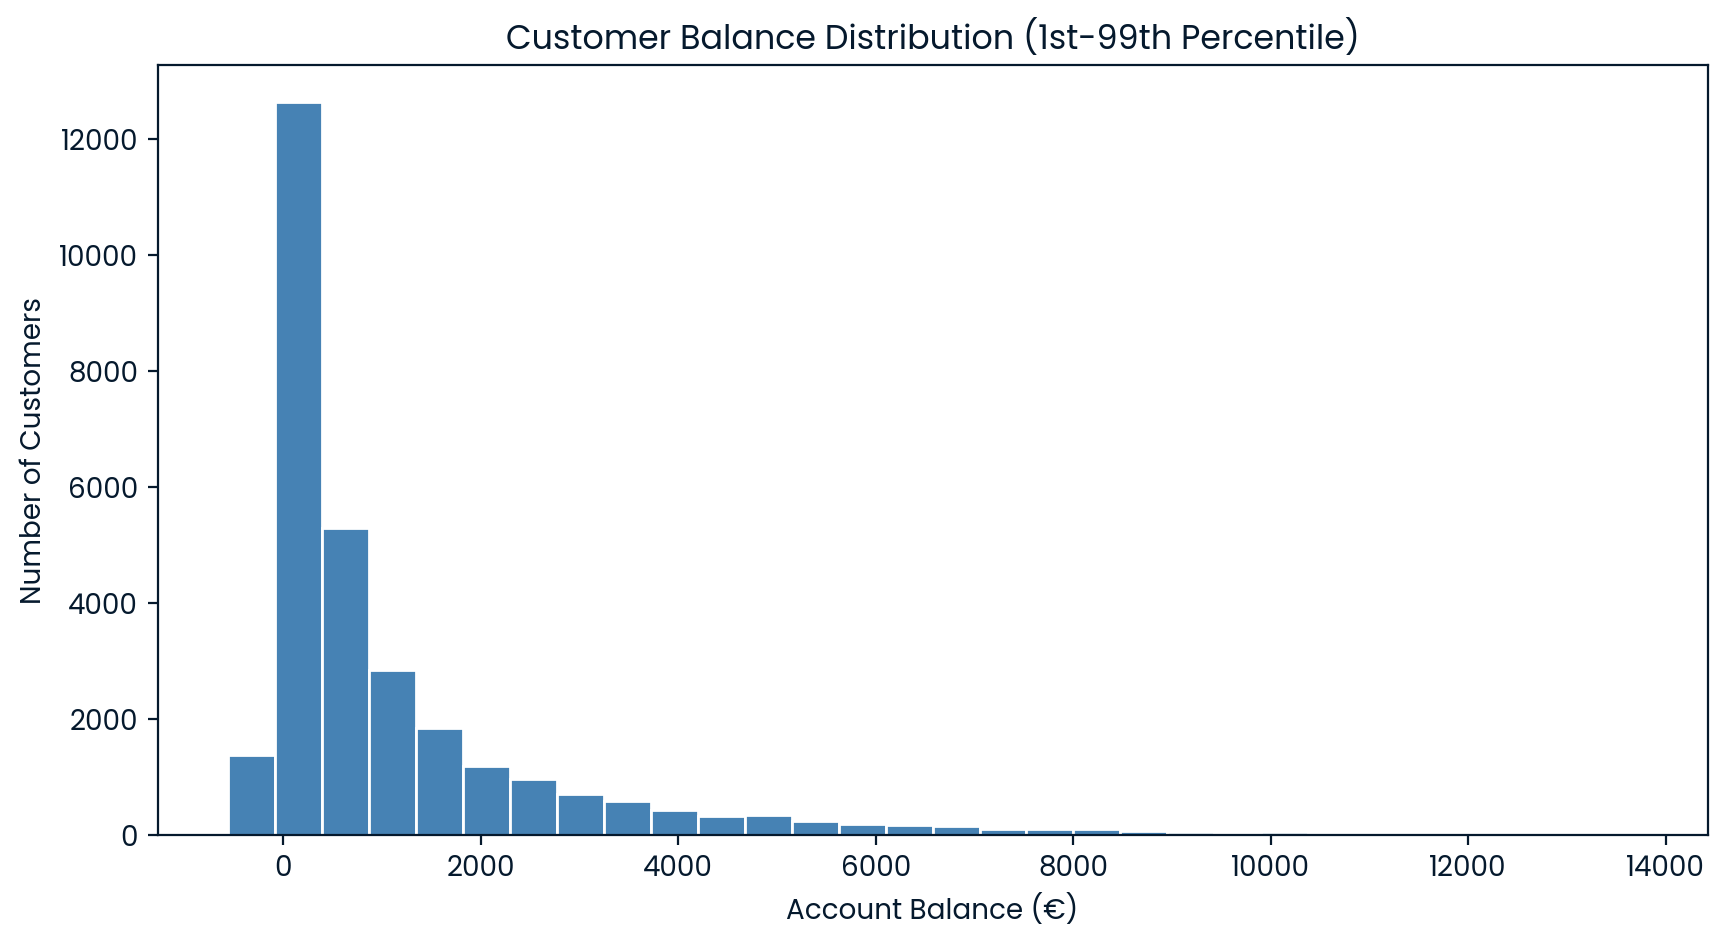

In [15]:
low = df['balance'].quantile(0.01)
high = df['balance'].quantile(0.99)

balance_filtered = df[(df['balance'] >= low) & (df['balance'] <= high)]['balance']

plt.figure(figsize=(10, 5))
plt.hist(balance_filtered, bins=30, color='steelblue', edgecolor='white')
plt.title('Customer Balance Distribution (1st-99th Percentile)')
plt.xlabel('Account Balance (€)')
plt.ylabel('Number of Customers')
plt.show()

## Insight 4: Customer Balance Distribution

A significant proportion of customers hold near-zero or negative balances, making them 
unlikely candidates for a term deposit product which requires locking funds away. 
Marketing to this segment represents wasted spend. We recommend the business focuses 
outreach on customers with balances between £1,500 and £3,500, a segment with enough 
financial stability to consider saving, while remaining large enough in volume to drive 
meaningful conversion numbers.

In [16]:
print(df['loan'].value_counts())
print(df['default'].value_counts())

loan
0    25786
1     5119
Name: count, dtype: int64
default
0    30395
1      510
Name: count, dtype: int64


## Insight 5: Ideal Customer Persona

Meet Wise Wendy, our ideal term deposit customer. She is between 25 and 40, works in 
management, a technical role, or is an aspiring professional who is simply good with 
money. She holds at least a secondary education and maintains a account balance between 
£1,500 and £3,500, enough to feel financially stable without being wealthy. She has no 
personal loan because she avoids debt where possible, and she has never defaulted 
because she simply would not put herself in that position. Every campaign for this 
product should start with Wendy in mind.

# Act 3: What Predicts Conversion?
## Testing Our Hypotheses

In [17]:
print(df['y'].value_counts())
print(df['y'].value_counts(normalize=True).round(3) * 100)

y
0    26392
1     4513
Name: count, dtype: int64
y
0    85.4
1    14.6
Name: proportion, dtype: float64


In [18]:
df.groupby('y')['balance'].median()

y
0    429.0
1    757.0
Name: balance, dtype: float64

In [19]:
from scipy import stats

converted = df[df['y'] == 1]['balance']
not_converted = df[df['y'] == 0]['balance']

stat, p_value = stats.mannwhitneyu(converted, not_converted)
print(f'P-value: {p_value}')

P-value: 6.432548504493088e-81


## Insight 6: Balance and Conversion Are Statistically Linked

Customers who converted had a median balance of £757 compared to £429 for those 
who did not. To confirm this difference was not due to random chance, we applied 
a Mann-Whitney U test, which returned a p-value effectively equal to zero. This 
means we can say with confidence that balance is a genuine predictor of conversion, 
not a coincidence in the data. The business should prioritise outreach toward 
customers with higher balances, as they are statistically more likely to convert.

In [20]:
df.groupby('y')['age'].median()

y
0    39.0
1    38.0
Name: age, dtype: float64

In [21]:
df['age_group'] = pd.cut(df['age'], 
                          bins=[18, 30, 40, 50, 65, 100], 
                          labels=['18-30', '31-40', '41-50', '51-65', '65+'])

df.groupby('age_group')['y'].mean().round(3) * 100

age_group
18-30    20.0
31-40    12.8
41-50    11.3
51-65    14.9
65+      43.1
Name: y, dtype: float64

## Insight 7: Age Groups and Conversion Rates

Analysis of conversion rates by age group reveals that the 65+ demographic converts 
at 43.1%, nearly three times higher than any other group, while the 18-30 segment 
converts at 20%. By contrast, the 31 to 50 age range, which represents the majority 
of our customer base, converts at only 11 to 13%. This suggests the business has been 
optimising for reach rather than effectiveness, targeting the largest age groups rather 
than the most responsive ones. We recommend shifting a meaningful portion of campaign 
budget toward the 65+ and 18-30 segments. The 31 to 50 group should not be abandoned 
entirely given its volume, but it should no longer receive a disproportionate share 
of outreach resources.

In [22]:
df.groupby('loan')['y'].mean().round(3) * 100

loan
0    15.9
1     7.9
Name: y, dtype: float64

In [23]:
df.groupby('default')['y'].mean().round(3) * 100


default
0    14.7
1     6.7
Name: y, dtype: float64

## Insight 8: Debt Status and Conversion Rates

Customers who are in debt are less likely to convert to term deposits because they 
have little money to spare and less financial flexibility. Customers who have never 
defaulted convert at 14.7% compared to just 6.7% for those who have, while customers 
with no existing loan convert at 15.9% versus 7.9% for those with one. In both cases 
the conversion rate for indebted customers is roughly half that of those without 
financial commitments. The marketing team should prioritise outreach toward customers 
with no existing loans and no default history, as they are statistically twice as 
likely to convert.

In [26]:
cat_cols = ['job', 'education', 'contact', 'month', 'poutcome', 'marital']

df_model = pd.get_dummies(df, columns=cat_cols, drop_first=True)
df_model.shape

(30905, 42)

In [27]:
drop_cols = ['y', 'duration', 'age_group']

X = df_model.drop(columns=drop_cols)
y = df_model['y']

print(X.shape)
print(y.shape)

(30905, 39)
(30905,)


In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training set: {X_train.shape}')
print(f'Test set: {X_test.shape}')

Training set: (24724, 39)
Test set: (6181, 39)


In [31]:
df_model['pdays'] = df_model['pdays'].fillna(0)

X = df_model.drop(columns=drop_cols)
y = df_model['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [32]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.98      0.93      5300
           1       0.58      0.18      0.28       881

    accuracy                           0.86      6181
   macro avg       0.73      0.58      0.60      6181
weighted avg       0.84      0.86      0.83      6181



In [33]:
model_balanced = LogisticRegression(
    max_iter=1000, 
    random_state=42,
    class_weight='balanced'
)
model_balanced.fit(X_train, y_train)

y_pred_balanced = model_balanced.predict(X_test)
print(classification_report(y_test, y_pred_balanced))

              precision    recall  f1-score   support

           0       0.92      0.79      0.85      5300
           1       0.32      0.59      0.42       881

    accuracy                           0.76      6181
   macro avg       0.62      0.69      0.63      6181
weighted avg       0.83      0.76      0.79      6181



In [34]:
import pandas as pd

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model_balanced.coef_[0]
}).sort_values('coefficient', ascending=False)

print(feature_importance.head(10))
print(feature_importance.tail(10))

                     feature  coefficient
36          poutcome_success     1.831760
29                 month_mar     0.683230
28                 month_jun     0.640296
32                 month_oct     0.604355
33                 month_sep     0.578122
17               job_student     0.407726
9   was_previously_contacted     0.400434
21        education_tertiary     0.374967
14               job_retired     0.350917
38            marital_single     0.332306
              feature  coefficient
10    job_blue-collar    -0.213716
25          month_feb    -0.217869
30          month_may    -0.286371
22  contact_telephone    -0.310124
27          month_jul    -0.451079
4                loan    -0.558446
26          month_jan    -0.583467
3             housing    -0.658471
23          month_aug    -0.771490
31          month_nov    -0.801257


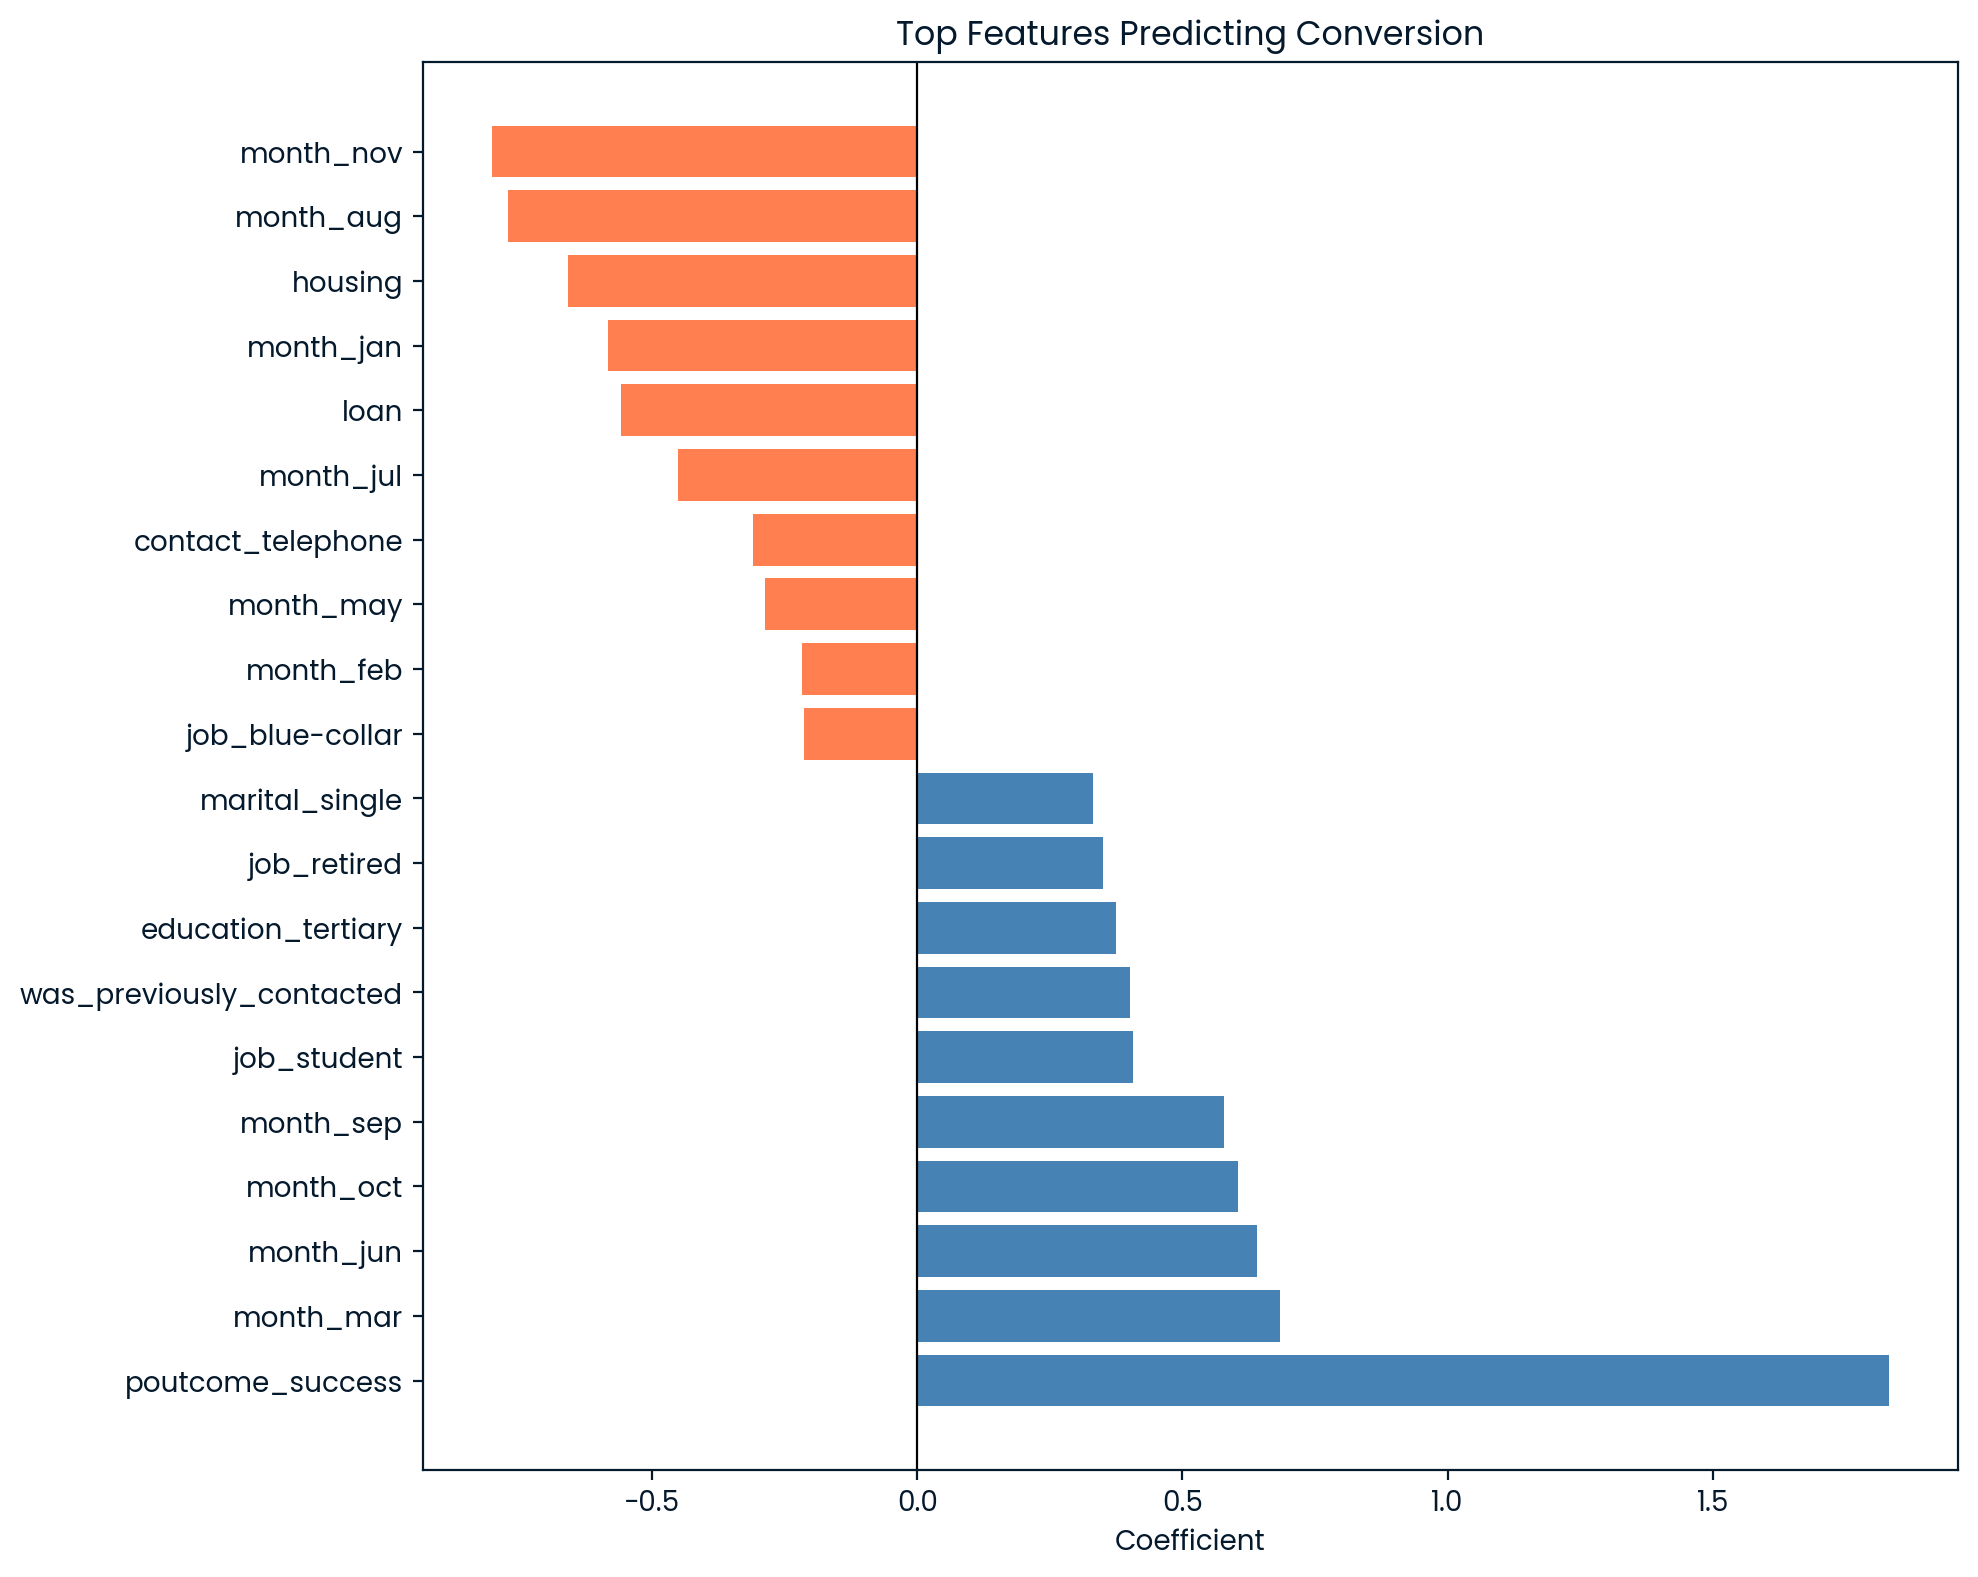

In [35]:
top_features = pd.concat([
    feature_importance.head(10),
    feature_importance.tail(10)
])

colors = ['steelblue' if x > 0 else 'coral' for x in top_features['coefficient']]

plt.figure(figsize=(10, 8))
plt.barh(top_features['feature'], top_features['coefficient'], color=colors)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Top Features Predicting Conversion')
plt.xlabel('Coefficient')
plt.tight_layout()
plt.show()

## Insight 9: Key Predictors of Conversion (Logistic Regression Model)

Our logistic regression model identified the features most strongly associated 
with conversion. Previous campaign success (poutcome_success) is by far the 
strongest predictor, nearly three times more influential than any other feature. 
Customers who converted before are highly likely to convert again, making them 
the highest priority segment for any future campaign. Campaign timing also emerges 
as a significant factor, with March, June, September and October being the strongest 
months for conversion, while November, August and January are the weakest. Finally, 
customers with existing housing loans are among the least likely to convert, 
reinforcing our earlier finding that financial commitments reduce conversion 
likelihood. The business should prioritise previously converted customers, schedule 
campaigns in high performing months, and deprioritise customers with existing 
housing or personal loans.

# Final Recommendations

Based on our analysis of 30,905 bank customers, including demographic profiling, 
financial behaviour analysis, statistical hypothesis testing, and logistic regression 
modelling, we present the following actionable recommendations for the Strategy and 
Marketing teams.

## 1. Prioritise Previously Converted Customers
Customers who responded positively to a previous campaign are by far the strongest 
predictor of conversion, nearly three times more influential than any other factor. 
These customers should be the first segment contacted in any future campaign.

## 2. Be Time Specific With Campaigns
Campaign timing has a significant impact on conversion likelihood. March, June, 
September and October consistently produce the strongest results. August, November 
and January should be avoided or used only for low cost outreach. The business is 
currently wasting budget by running campaigns outside of peak conversion windows.

## 3. Shift Age Targeting Toward 18-30 and 65+
The 31 to 50 age group represents the majority of our customer base but converts 
at only 11 to 13%. By contrast the 65+ segment converts at 43.1% and the 18 to 30 
segment at 20%. Campaign budget should be reallocated toward these two high converting 
groups rather than optimising for reach alone.

## 4. Deprioritise Customers With Existing Financial Commitments
Customers with personal loans convert at 7.9% compared to 15.9% for those without, 
and customers with housing loans are among the weakest performers in our model. 
Removing these segments from primary outreach would significantly improve campaign 
efficiency.

## 5. Build Campaigns Around Wise Wendy
Our ideal customer is aged 25 to 40, holds a balance between £1,500 and £3,500, 
has no existing loans, has never defaulted, and works in management, a technical 
role, or a financially responsible profession. Every campaign asset, message, and 
channel decision should be tested against whether it speaks to Wise Wendy first.